# Notebook 3: Strait of Hormuz — Ship Arrivals Cleaning

**Source:** IMF PortWatch (portwatch.imf.org) / UN Global Platform  
**Granularity:** Daily --> Monthly (resampled)  
**Scope:** 2020–2025  
**Vessel types:** Container, Dry Bulk, General Cargo, Roll-on/roll-off (Ro-Ro), Tanker  
**Focus:** Tanker vessels (≈60.5% of all transits, the key proxy for crude oil throughput)  

**Pipeline steps covered:** Data Ingestion --> Data Cleaning --> Data Wrangling

> **Note:** Export the CSV from portwatch.imf.org  
> (Port: Strait of Hormuz --> Export Data --> CSV). The expected columns are  
> `date`, `vessel_type` (or separate columns per vessel type), and `count` (arrivals).

This notebook was the most unfamiliar to set up. I initially did not know what the Strait of Hormuz data would look like or whether it would come in wide or long format, and I was unsure how tanker counts connected to oil prices before researching the route's role in global supply.

## 1. Imports & Configuration

In [1]:
import pandas as pd               # loads and manipulates data tables
import numpy as np                # math operations
import matplotlib.pyplot as plt   # draws charts
import matplotlib.dates as mdates # formats date labels on chart axes
import os                         # used to create the figures/ folder
                                  # before saving charts
import warnings
warnings.filterwarnings('ignore')

START_DATE = '2020-01-01'         # earliest date we want to keep
END_DATE   = '2025-12-31'         # latest date we want to keep

# full list of vessel types in the PortWatch export
VESSEL_TYPES = ['Container',
                'Dry Bulk',
                'General Cargo',
                'Roll-on/roll-off',
                'Tanker']

# Tanker is the vessel type that carries crude oil
# it's the only one directly relevant to our energy price analysis
PRIMARY_VESSEL = 'Tanker'

print('Libraries loaded.')

Libraries loaded.


## 2. Data Ingestion

I wasn't sure at first whether to download all vessel types or just tankers. I kept all five because dropping them before inspection felt premature, I wanted to see the full picture first and confirm tankers were actually the dominant category before narrowing.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
RAW_PATH = '/content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/InputCSVfiles/arrivals-of-ships.csv'

df_raw = pd.read_csv(RAW_PATH)

print(f'Raw shape: {df_raw.shape}')
# confirms DateTime + 5 vessel types + 2 moving average cols
print(f'Columns  : {list(df_raw.columns)}')
df_raw.head(10)

Raw shape: (2666, 8)
Columns  : ['DateTime', 'Container', 'Dry Bulk', 'General Cargo', 'Roll-on/roll-off', 'Tanker', '7-day Moving Average', 'Prior Year: 7-day Moving Average']


,DateTime,Container,Dry Bulk,General Cargo,Roll-on/roll-off,Tanker,7-day Moving Average,Prior Year: 7-day Moving Average
0,2019-01-01 00:00:00,7,8,2,3,35,NaN,NaN
1,2019-01-02 00:00:00,9,11,0,3,42,NaN,NaN
2,2019-01-03 00:00:00,10,11,4,0,50,NaN,NaN
3,2019-01-04 00:00:00,9,12,2,2,41,NaN,NaN
4,2019-01-05 00:00:00,11,13,4,1,33,NaN,NaN
5,2019-01-06 00:00:00,5,16,2,1,35,NaN,NaN
6,2019-01-07 00:00:00,11,7,4,1,56,65.857143,NaN
7,2019-01-08 00:00:00,8,10,5,1,31,65.857143,NaN
8,2019-01-09 00:00:00,8,9,4,2,25,63.428571,NaN
9,2019-01-10 00:00:00,9,12,5,3,39,62.428571,NaN


## 3. Initial Inspection

In [4]:
print('dtypes')
print(df_raw.dtypes)
print()
print('Missing values')
print(df_raw.isnull().sum())
print()
print('Value counts for key columns (first categorical col)')

# If dataset is long-format (date, vessel_type, count)
# this will show vessel types
for col in df_raw.select_dtypes(include='object').columns:
    print(f'[{col}]:', df_raw[col].unique()[:10])

dtypes
DateTime                             object
Container                             int64
Dry Bulk                              int64
General Cargo                         int64
Roll-on/roll-off                      int64
Tanker                                int64
7-day Moving Average                float64
Prior Year: 7-day Moving Average    float64
dtype: object

Missing values
DateTime                              0
Container                             0
Dry Bulk                              0
General Cargo                         0
Roll-on/roll-off                      0
Tanker                                0
7-day Moving Average                  6
Prior Year: 7-day Moving Average    371
dtype: int64

Value counts for key columns (first categorical col)
[DateTime]: ['2019-01-01 00:00:00' '2019-01-02 00:00:00' '2019-01-03 00:00:00'
 '2019-01-04 00:00:00' '2019-01-05 00:00:00' '2019-01-06 00:00:00'
 '2019-01-07 00:00:00' '2019-01-08 00:00:00' '2019-01-09 00:00:00'
 '2019-01-1

## 4. Schema Handling
The PortWatch export format wasn't documented clearly when I first downloaded it. I wasn't sure if the data would have one column per vessel type (wide) or one row per vessel type per day (long). Writing the auto-detection logic to handle both formats was more involved than expected but made the notebook more robust.

PortWatch exports may come in two formats. The cells below handle both automatically:
- **Wide format:** columns = `date, Tanker, Container, Dry Bulk, ...`  
- **Long format:** columns = `date, vessel_type, count`

In [5]:
df = df_raw.copy() # work on a copy so the original stays untouched

# detect the date column by checking if 'date' or 'time'
# appears in any column name
date_candidates = [c for c in df.columns
                   if 'date' in c.lower() or 'time' in c.lower()]
DATE_COL = date_candidates[0] if date_candidates else df.columns[0]
# takes the first match, or falls back to the first column if nothing matches
print(f'Date column detected: "{DATE_COL}"')

df[DATE_COL] = pd.to_datetime(df[DATE_COL], infer_datetime_format=True)

#  Detect format: wide vs long
vessel_cols_found = [c for c in df.columns
                     if any(v.lower() in c.lower()
                     for v in VESSEL_TYPES)]

if vessel_cols_found:
    # Wide format — vessel types are columns
    print(f'Wide format detected. Vessel columns: {vessel_cols_found}')
    df = df[[DATE_COL] + vessel_cols_found].copy()
    df = df.set_index(DATE_COL).sort_index()
    df.index.name = 'date'
    df_wide = df
else:
    # Long format — pivot to wide
    print('Long format detected. Pivoting to wide...')
    type_col  = [c for c in df.columns
                 if 'type' in c.lower()
                 or 'vessel' in c.lower()][0]
    count_col = [c for c in df.columns
                 if 'count' in c.lower()
                 or 'arrival' in c.lower()
                 or 'transit' in c.lower()][0]
    df_wide = df.pivot_table(index=DATE_COL,
                             columns=type_col,
                             values=count_col,
                             aggfunc='sum')
    df_wide.index.name = 'date'
    df_wide = df_wide.sort_index()

print(f'Wide-format shape: {df_wide.shape}')
df_wide.head()

Date column detected: "DateTime"
Wide format detected. Vessel columns: ['Container', 'Dry Bulk', 'General Cargo', 'Roll-on/roll-off', 'Tanker']
Wide-format shape: (2666, 5)


,Container,Dry Bulk,General Cargo,Roll-on/roll-off,Tanker
date,,,,,
2019-01-01,7,8,2,3,35
2019-01-02,9,11,0,3,42
2019-01-03,10,11,4,0,50
2019-01-04,9,12,2,2,41
2019-01-05,11,13,4,1,33


## 5. Filter to Date Range of Interest

In [6]:
df_wide = df_wide.loc[START_DATE:END_DATE]
print(f'After date filter - shape: {df_wide.shape}')
print(f'Date range: {df_wide.index.min().date()}->{df_wide.index.max().date()}')

After date filter - shape: (2192, 5)
Date range: 2020-01-01->2025-12-31


## 6. Handle Missing Values

Notable pattern observed in the PortWatch chart: a sharp drop to ~0 around **March 2026**  
and possibly around **early 2024**
(Houthi disruption period).

(I searched up what happend to the Strait during this period)

These are likely **real geopolitical events** --> So removing them would have erased the most important signal in the dataset. That distinction between a data problem and a real-world event wasn't something I had considered before looking into what was actually happening at the strait.

Strategy:
- Short gaps (1–3 days): forward-fill (reporting latency)
- Sustained near-zero periods: **preserve as-is** (they represent real disruptions)
- Flag sustained gaps with an `event_flag` column for use in analysis

In [7]:
# Reindex to full daily calendar
full_index = pd.date_range(START_DATE, END_DATE, freq='D')
df_wide = df_wide.reindex(full_index)
df_wide.index.name = 'date'

print('Nulls BEFORE imputation:')
print(df_wide.isnull().sum())

# Forward-fill short gaps only (limit=3 days)
df_filled = df_wide.ffill(limit=3)

print('\nNulls AFTER forward-fill (limit=3):')
print(df_filled.isnull().sum())

# For any remaining nulls (long gaps), fill with 0 and flag
# A 0 here means 'no data reported' — distinguish this in analysis
remaining_null_dates = df_filled[df_filled.isnull().any(axis=1)].index
if not remaining_null_dates.empty:
    print(f'\nLong-gap null dates ({len(remaining_null_dates)})-filling with 0 & flagging:')
    print(remaining_null_dates[:10])
df_filled = df_filled.fillna(0)

Nulls BEFORE imputation:
Container           0
Dry Bulk            0
General Cargo       0
Roll-on/roll-off    0
Tanker              0
dtype: int64

Nulls AFTER forward-fill (limit=3):
Container           0
Dry Bulk            0
General Cargo       0
Roll-on/roll-off    0
Tanker              0
dtype: int64


In [8]:
total_daily = df_filled.sum(axis=1)
rolling_mean = total_daily.rolling(window=90, min_periods=30).mean()
df_filled['disruption_flag'] = ((total_daily < rolling_mean * 0.5) &
 (rolling_mean > 0)).astype(int)

flagged_days = df_filled[df_filled['disruption_flag'] == 1]
print(f'Disruption-flagged days: {len(flagged_days)}')
if not flagged_days.empty:
    print(flagged_days.index.min().date(), '-->',
          flagged_days.index.max().date())

Disruption-flagged days: 0


## 7. Resample: Daily  Monthly

Sum arrivals per month (count data, summing is correct, not averaging).  
For the disruption flag, take the max (1 if any disruption day in that month).

In [9]:
# separate the vessel columns from the flag column before resampling
vessel_cols_clean = [c for c in df_filled.columns if c != 'disruption_flag']

# sum daily arrivals into monthly totals
# summing is correct for count data cuz we want total ships per month
# not the average
df_monthly = df_filled[vessel_cols_clean].resample('ME').sum()

# for the disruption flag, take the max per month
# max of 0s and 1s = 1 if ANY day in that month was flagged, 0 if none were
df_monthly['disruption_flag'] = df_filled['disruption_flag'].resample('ME').max()

# total arrivals across all vessel types each month
df_monthly['Total_Arrivals'] = df_monthly[vessel_cols_clean].sum(axis=1)

# tamker share as a percentage of all monthly arrivals
tanker_col = [c for c in vessel_cols_clean if 'tanker' in c.lower()]
if tanker_col:
    df_monthly['Tanker_Share_pct'] = (
        df_monthly[tanker_col[0]] /
        df_monthly['Total_Arrivals'].replace(0,
                                             np.nan) * 100
    ).round(2)
    # replace(0, NaN) prevents division by zero
    # in months with no reported arrivals

df_monthly.index.name = 'YearMonth' # renames index to match the join key
                                    # in Notebooks 1 and 2

print(f'Monthly shape: {df_monthly.shape}')
df_monthly.head(12)

Monthly shape: (72, 8)


,Container,Dry Bulk,General Cargo,Roll-on/roll-off,Tanker,disruption_flag,Total_Arrivals,Tanker_Share_pct
YearMonth,,,,,,,,
2020-01-31,319,370,106,46,1234,0,2075,59.47
2020-02-29,279,352,92,40,1182,0,1945,60.77
2020-03-31,287,341,83,51,1248,0,2010,62.09
2020-04-30,322,374,119,50,1411,0,2276,61.99
2020-05-31,370,414,120,61,1516,0,2481,61.10
2020-06-30,398,397,126,49,1564,0,2534,61.72
2020-07-31,379,403,121,47,1600,0,2550,62.75
2020-08-31,394,445,115,42,1632,0,2628,62.10
2020-09-30,427,510,133,45,1563,0,2678,58.36


## 8. Visualisation

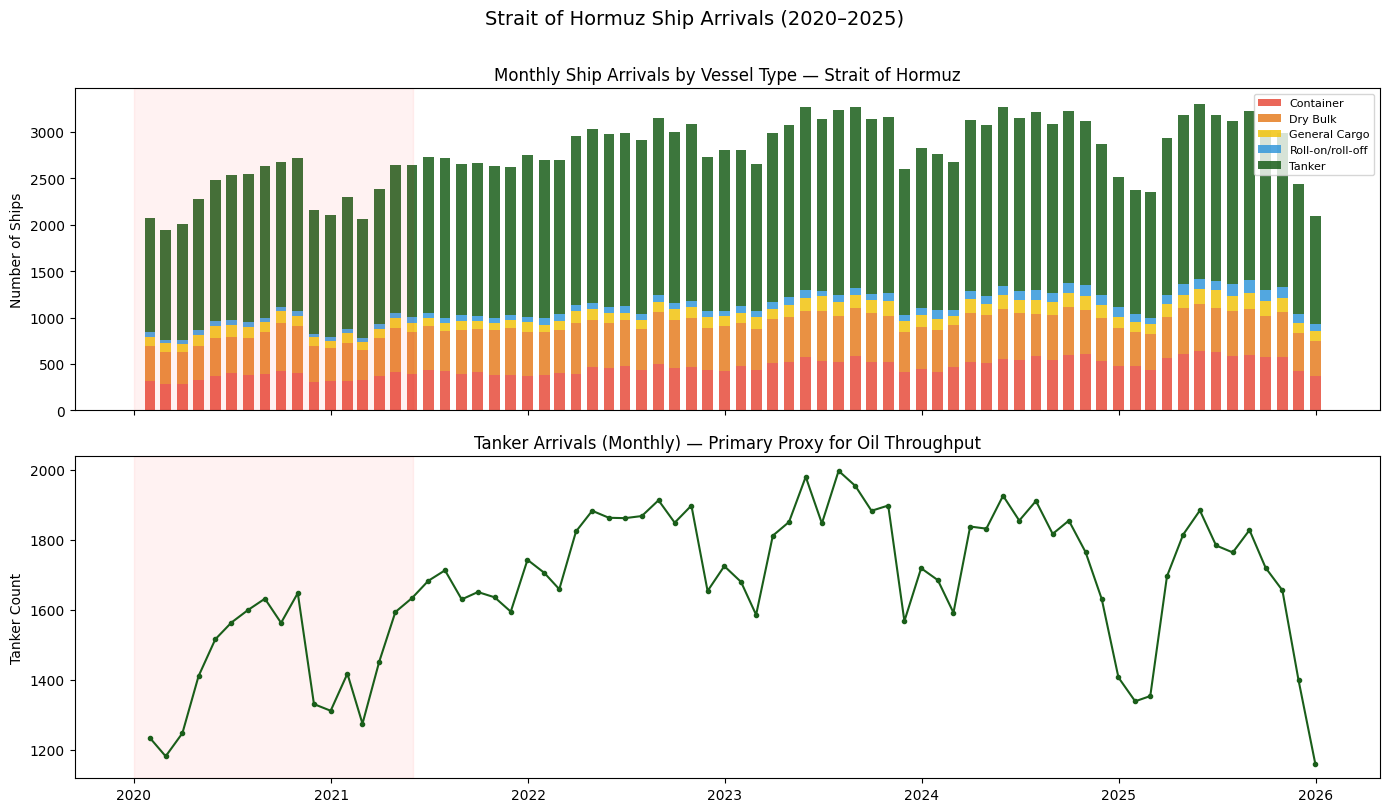

In [10]:
# 2 stacked subplots sharing the same x-axis (time)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Stacked bar: arrivals by vessel type
plot_cols = [c for c in vessel_cols_clean if c in df_monthly.columns]
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#1a5e1a']
bottom = np.zeros(len(df_monthly))
for col, color in zip(plot_cols, colors[:len(plot_cols)]):
    axes[0].bar(df_monthly.index, df_monthly[col], bottom=bottom,
                label=col, color=color, width=20, alpha=0.85)
    bottom += df_monthly[col].values

# Mark disruption months
disrupted = df_monthly[df_monthly['disruption_flag'] == 1]
for ts in disrupted.index:
    axes[0].axvline(ts, color='black', lw=0.8, ls='--', alpha=0.4)

axes[0].set_title('Monthly Ship Arrivals by Vessel Type — Strait of Hormuz')
axes[0].set_ylabel('Number of Ships')
axes[0].legend(loc='upper right', fontsize=8)

# Tanker arrivals only
if tanker_col:
    axes[1].plot(df_monthly.index,
                 df_monthly[tanker_col[0]],
                 lw=1.5,
                 color='#1a5e1a',
                 marker='o',
                 markersize=3)
    axes[1].set_title('Tanker Arrivals (Monthly) — Primary Proxy for Oil Throughput')
    axes[1].set_ylabel('Tanker Count')
    for ts in disrupted.index:
        axes[1].axvline(ts, color='black', lw=0.8, ls='--', alpha=0.4)

for ax in axes:
    ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
               alpha=0.05, color='red')

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Strait of Hormuz Ship Arrivals (2020–2025)',
             fontsize=14,
             y=1.01)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/hormuz_arrivals_monthly.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

## 9. Final Validation & Save

In [11]:
print('Final dataset')
print(f'Shape      : {df_monthly.shape}')
print(f'Date range : {df_monthly.index.min().date()}->{df_monthly.index.max().date()}')
print(f'Nulls      : {df_monthly.isnull().sum().to_dict()}')
print()
print(df_monthly.describe())

Final dataset
Shape      : (72, 8)
Date range : 2020-01-31->2025-12-31
Nulls      : {'Container': 0, 'Dry Bulk': 0, 'General Cargo': 0, 'Roll-on/roll-off': 0, 'Tanker': 0, 'disruption_flag': 0, 'Total_Arrivals': 0, 'Tanker_Share_pct': 0}

        Container    Dry Bulk  General Cargo  Roll-on/roll-off       Tanker  \
count   72.000000   72.000000      72.000000         72.000000    72.000000   
mean   458.277778  460.208333     120.305556         74.013889  1670.250000   
std     90.817759   53.771016      26.779559         23.278167   208.564899   
min    279.000000  316.000000      74.000000         40.000000  1161.000000   
25%    395.500000  438.000000     102.000000         57.000000  1581.500000   
50%    444.500000  471.500000     115.500000         68.500000  1690.500000   
75%    526.250000  499.500000     141.000000         92.500000  1847.500000   
max    639.000000  556.000000     188.000000        135.000000  1997.000000   

       disruption_flag  Total_Arrivals  Tanker_Sh

In [12]:
OUT_PATH = '/content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/OutputCSVFiles/hormuz_arrivals_monthly.csv'
df_monthly.to_csv(OUT_PATH)
print(f'Saved --> {OUT_PATH}')

Saved --> /content/drive/MyDrive/DataSources&Manipulation/INST447-FinalProject/OutputCSVFiles/hormuz_arrivals_monthly.csv


## 10. Cleaning Summary

| Step | Action | Rationale |
|------|--------|-----------|
| Schema detection | Auto-handles wide & long formats | PortWatch export format may vary |
| Date filter | 2020 → 2025 | Project scope |
| Reindex to daily calendar | Expose implicit gaps | Makes missing days visible |
| Forward-fill (limit=3) | Short reporting delays | Standard for AIS/vessel data |
| Sustained gaps → 0 + flag | Preserved real disruption periods | Houthi attacks, geopolitical events are analytically important |
| Monthly resampling | Sum (count data) | Correct aggregation for arrival counts |
| Tanker share % added | Derived column | Key metric for oil throughput proxy |
| Disruption flag | Max per month | Allows filtering/controlling in regression |

**Output:** `data/clean/hormuz_arrivals_monthly.csv`  
**Join key:** `YearMonth` (month-end date, e.g. `2020-01-31`)  

> **For cross-channel analysis:** join on `YearMonth` with  
> - `commodity_prices_monthly.csv` (WTI/Brent/Natural Gas)  
> - `cpi_inflation_monthly.csv` (CPI, MoM%, YoY%)